# KMeans From Scratch

This Jupyter Notebook provides a detailed, step-by-step guide on implementing the KMeans clustering algorithm from scratch. It covers the following key areas:
- Sample data points
- Select initial cluster centers
- Iteratively update cluster centers

In [1]:
import random
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(cmap.N)]

mpl.rcParams["font.size"] = 24
mpl.rcParams["lines.linewidth"] = 2

seed = 0
random.seed(seed)
np.random.seed(seed)
n_samples = 10
markersize = 100

## Sample data points

In [2]:
# Sample 10 points
m1 = [1, 1]
cov1 = [[1, 0], [0, 1]]
s1 = np.random.multivariate_normal(m1, cov1, 5)

m2 = [-1, -1]
cov2 = [[1, -0.5], [-0.5, 1]]
s2 = np.random.multivariate_normal(m2, cov2, 5)

samples = np.concat([s1, s2])
np.random.shuffle(samples)

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

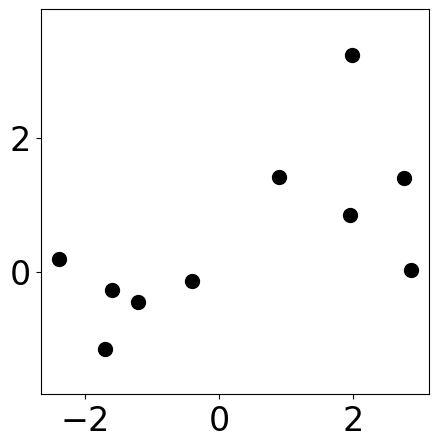

In [3]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=markersize, color="k")
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.axis("equal")

## Select initial cluster centers

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

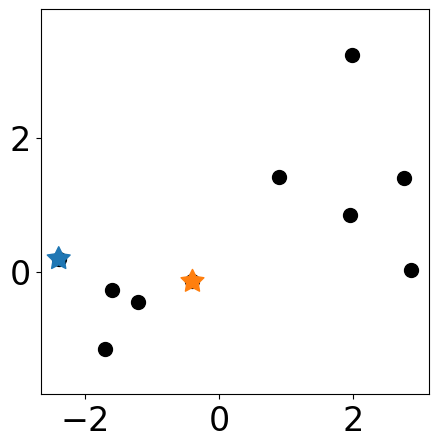

In [4]:
## any two clusters
cluster_ids = [0, 2]
centers = samples[cluster_ids]
k = len(cluster_ids)


plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=markersize, color="k")
plt.scatter(centers[:,0], centers[:, 1],
            s=markersize*3, c=colors[:k], marker=(5, 1))

plt.axis("equal")

## Iteratively update cluster centers

In [5]:
def kmeans(centers, data, steps):
    k = len(centers)
    losses = []
    labels = []
    for _ in range(steps):
        distances = np.linalg.norm(data[:, np.newaxis] - centers, axis=2)
        labels = np.argmin(distances, axis=1)
        diff = data - centers[labels]
        loss = np.sum(diff**2)
        losses.append(loss)
        new_centers = np.array([data[labels == i].mean(axis=0) for i in range(k)])
        if np.all(centers == new_centers):
            print("Converged")
            break
        centers = new_centers
    return centers, labels, losses

### Run one step iteration

In [6]:
new_centers, labels, losses = kmeans(centers, samples, 1)

plot assignments

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

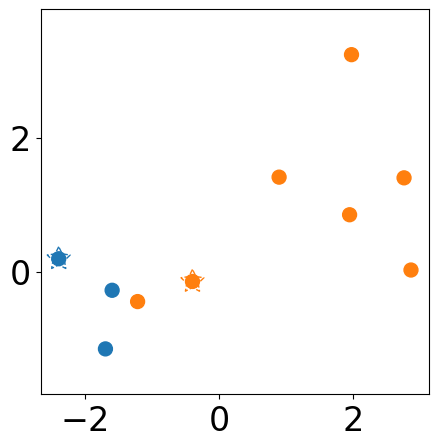

In [7]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1],
            s=markersize, color=[colors[l] for l in labels])

# old centers
plt.scatter(centers[:,0], centers[:, 1],
            s=markersize*3, edgecolor=colors, marker=(5, 1),
            facecolor="none", linestyle="dashed")

plt.axis("equal")

Plot Updated centers

(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

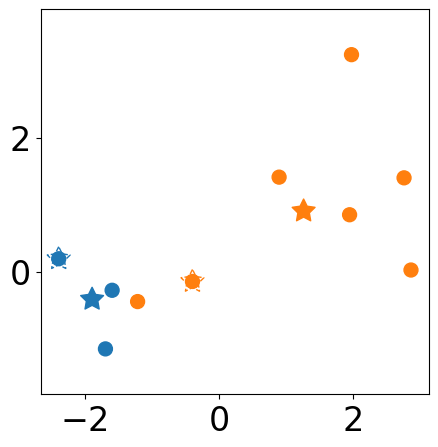

In [8]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1],
            s=markersize, color=[colors[l] for l in labels])

# old centers
plt.scatter(centers[:,0], centers[:, 1],
            s=markersize*3, edgecolor=colors[:k], marker=(5, 1),
            facecolor="none", linestyle="dashed")

# new centers
plt.scatter(new_centers[:,0], new_centers[:, 1],
            s=markersize*3, c=colors[:k], marker=(5, 1))

plt.axis("equal")

### Run until converge

In [9]:
new_centers, labels, losses = kmeans(centers, samples, 10)

Converged


(np.float64(-2.659691942232599),
 np.float64(3.1307603678824707),
 np.float64(-1.3757641112226862),
 np.float64(3.4607340235073694))

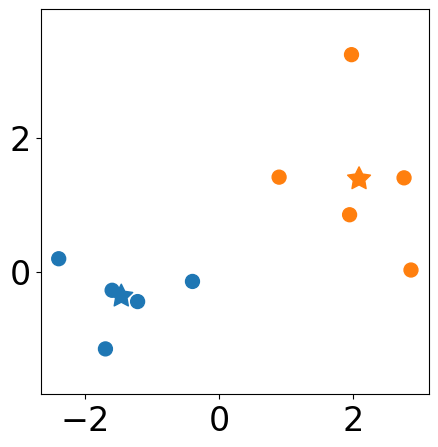

In [10]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1],
            s=markersize, color=[colors[l] for l in labels])

# new centers
plt.scatter(new_centers[:,0], new_centers[:, 1],
            s=markersize*3, c=colors[:k], marker=(5, 1))

plt.axis("equal")

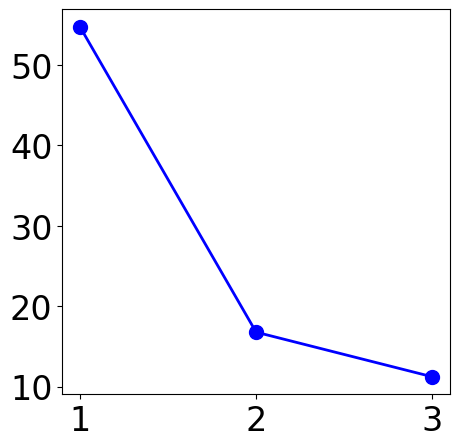

In [11]:
plt.figure(figsize=(5, 5))
plt.plot(range(1, len(losses)+1), losses, "o-", markersize=10, c="blue")

In [12]:
print(labels)

[0 1 0 0 1 1 1 0 1 0]
